<a href="https://colab.research.google.com/github/RatchanonPa/Data-Warehouse-and-Big-Data-Analytics/blob/main/Stock_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip /content/superai5-stock-price-prediction.zip

Archive:  /content/superai5-stock-price-prediction.zip
  inflating: X_test.csv              
  inflating: X_train.csv             
  inflating: sample_submission.csv   
  inflating: submission.csv          
  inflating: y_train.csv             


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [80]:
X_train = pd.read_csv('/content/X_train.csv')
X_test = pd.read_csv('/content/X_test.csv')
y_train = pd.read_csv('/content/y_train.csv')

In [5]:
X_train

,Id,High,Low,Open,Volume
0,0,1528.699951,1518.000000,1518.099976,214
1,1,1552.699951,1530.099976,1530.099976,107
2,2,1580.000000,1560.400024,1580.000000,416
3,3,1576.300049,1558.300049,1558.300049,47
4,4,1604.199951,1552.300049,1579.699951,236
...,...,...,...,...,...
638,638,1709.699951,1701.099976,1705.400024,721
639,639,1712.400024,1709.199951,1712.199951,264
640,640,1714.400024,1706.099976,1712.300049,1684
641,641,1708.500000,1699.500000,1707.099976,130


In [38]:
X_test

,Id,High,Low,Open,Volume
0,643,1735.000000,1713.000000,1713.300049,61
1,644,1732.000000,1719.000000,1727.000000,67
2,645,1718.000000,1717.699951,1718.000000,1
3,646,1719.099976,1719.099976,1719.099976,144865
4,647,1755.000000,1732.000000,1732.300049,37236
...,...,...,...,...,...
638,1281,2880.500000,2848.000000,2850.000000,4519
639,1282,2871.699951,2836.300049,2865.199951,3116
640,1283,2889.500000,2857.800049,2859.899902,1822
641,1284,2916.100098,2863.800049,2864.199951,2237


In [39]:
y_train

,Id,Close
0,0,1524.500000
1,1,1549.199951
2,2,1566.199951
3,3,1571.800049
4,4,1557.400024
...,...,...
638,638,1702.400024
639,639,1709.199951
640,640,1710.000000
641,641,1699.500000


In [48]:
# ตรวจสอบว่าข้อมูลถูกต้องหรือไม่
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (643, 5)
y_train shape: (643, 2)
X_test shape: (643, 5)


In [49]:
# วิเคราะห์ข้อมูลเบื้องต้น
print("\nX_train info:")
print(X_train.info())
print("\nX_train description:")
print(X_train.describe())


X_train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      643 non-null    int64  
 1   High    643 non-null    float64
 2   Low     643 non-null    float64
 3   Open    643 non-null    float64
 4   Volume  643 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 25.2 KB
None

X_train description:
               Id         High          Low         Open         Volume
count  643.000000   643.000000   643.000000   643.000000     643.000000
mean   321.000000  1811.463608  1791.225506  1801.322552    4657.797823
std    185.762393   103.341969   103.898438   103.509904   25485.625516
min      0.000000  1484.000000  1452.099976  1469.300049       0.000000
25%    160.500000  1752.299988  1733.849976  1745.500000      90.500000
50%    321.000000  1813.500000  1799.300049  1805.800049     254.000000
75%    481.500000  1878.800049  1864.650

In [50]:
# เชื่อมข้อมูล X_train และ y_train เข้าด้วยกันโดยใช้คอลัมน์ Id
train_data = pd.merge(X_train, y_train, on='Id')

In [51]:
# ตรวจสอบว่ามี missing values หรือไม่
print("\nMissing values in train_data:")
print(train_data.isna().sum())


Missing values in train_data:
Id        0
High      0
Low       0
Open      0
Volume    0
Close     0
dtype: int64


In [52]:
# สร้างฟีเจอร์เพิ่มเติม
def add_features(df):
    # คำนวณ typical price (TP): (High + Low + Close) / 3
    if 'Close' in df.columns:
        df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3
    else:
        df['TP'] = (df['High'] + df['Low'] + df['Open']) / 3

    # คำนวณ price range
    df['Range'] = df['High'] - df['Low']

    # คำนวณ moving averages
    window_sizes = [5, 10, 20]

    for size in window_sizes:
        # Moving average for High
        df[f'High_MA{size}'] = df['High'].rolling(window=size).mean()
        # Moving average for Low
        df[f'Low_MA{size}'] = df['Low'].rolling(window=size).mean()
        # Moving average for Open
        df[f'Open_MA{size}'] = df['Open'].rolling(window=size).mean()
        # Moving average for Volume (Log transformation to handle outliers)
        df[f'Volume_MA{size}'] = np.log1p(df['Volume']).rolling(window=size).mean()

        if 'Close' in df.columns:
            # Moving average for Close
            df[f'Close_MA{size}'] = df['Close'].rolling(window=size).mean()
            # MACD like feature (difference between short and long MA)
            if size > 5:
                df[f'MACD_{size}'] = df['Close_MA5'] - df[f'Close_MA{size}']

    # Log transform Volume to handle outliers
    df['Volume_Log'] = np.log1p(df['Volume'])

    # Exponential weighted moving average
    if 'Close' in df.columns:
        df['EWMA5'] = df['Close'].ewm(span=5).mean()
        df['EWMA10'] = df['Close'].ewm(span=10).mean()
        df['EWMA20'] = df['Close'].ewm(span=20).mean()

    # Price momentum (rate of change)
    for period in [1, 3, 5, 10]:
        if 'Close' in df.columns:
            df[f'ROC_{period}'] = df['Close'].pct_change(periods=period)
        else:
            df[f'ROC_{period}'] = df['Open'].pct_change(periods=period)

    return df

# เพิ่มฟีเจอร์ให้กับข้อมูลทั้งหมด
train_data = add_features(train_data)

In [53]:
train_data

,Id,High,Low,Open,Volume,Close,TP,Range,High_MA5,Low_MA5,...,Close_MA20,MACD_20,Volume_Log,EWMA5,EWMA10,EWMA20,ROC_1,ROC_3,ROC_5,ROC_10
0,0,1528.699951,1518.000000,1518.099976,214,1524.500000,1523.733317,10.699951,NaN,NaN,...,NaN,NaN,5.370638,1524.500000,1524.500000,1524.500000,NaN,NaN,NaN,NaN
1,1,1552.699951,1530.099976,1530.099976,107,1549.199951,1543.999959,22.599976,NaN,NaN,...,NaN,NaN,4.682131,1539.319971,1538.084973,1537.467474,0.016202,NaN,NaN,NaN
2,2,1580.000000,1560.400024,1580.000000,416,1566.199951,1568.866659,19.599976,NaN,NaN,...,NaN,NaN,6.033086,1552.052593,1549.387008,1548.017868,0.010973,NaN,NaN,NaN
3,3,1576.300049,1558.300049,1558.300049,47,1571.800049,1568.800049,18.000000,NaN,NaN,...,NaN,NaN,3.871201,1560.255382,1556.771106,1554.883416,0.003576,0.031027,NaN,NaN
4,4,1604.199951,1552.300049,1579.699951,236,1557.400024,1571.300008,51.899902,1568.379980,1543.820020,...,NaN,NaN,5.468060,1559.159250,1556.951651,1555.492162,-0.009161,0.005293,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,638,1709.699951,1701.099976,1705.400024,721,1702.400024,1704.399984,8.599976,1725.319971,1713.780005,...,1781.354999,-62.474994,6.582025,1718.370340,1737.950792,1767.233106,-0.001232,-0.012128,-0.021946,-0.056372
639,639,1712.400024,1709.199951,1712.199951,264,1709.199951,1710.266642,3.200073,1720.459985,1709.619995,...,1774.529999,-59.810004,5.579730,1715.313544,1732.723367,1761.706139,0.003994,-0.014416,-0.012023,-0.049864
640,640,1714.400024,1706.099976,1712.300049,1684,1710.000000,1710.166667,8.300049,1716.239990,1706.179980,...,1768.250000,-56.190015,7.429521,1713.542362,1728.591846,1756.781745,0.000468,0.003227,-0.007718,-0.029402
641,641,1708.500000,1699.500000,1707.099976,130,1699.500000,1702.500000,9.000000,1711.100000,1704.079980,...,1761.495001,-56.375006,4.875197,1708.861575,1723.302419,1751.326340,-0.006140,-0.001703,-0.020009,-0.020405


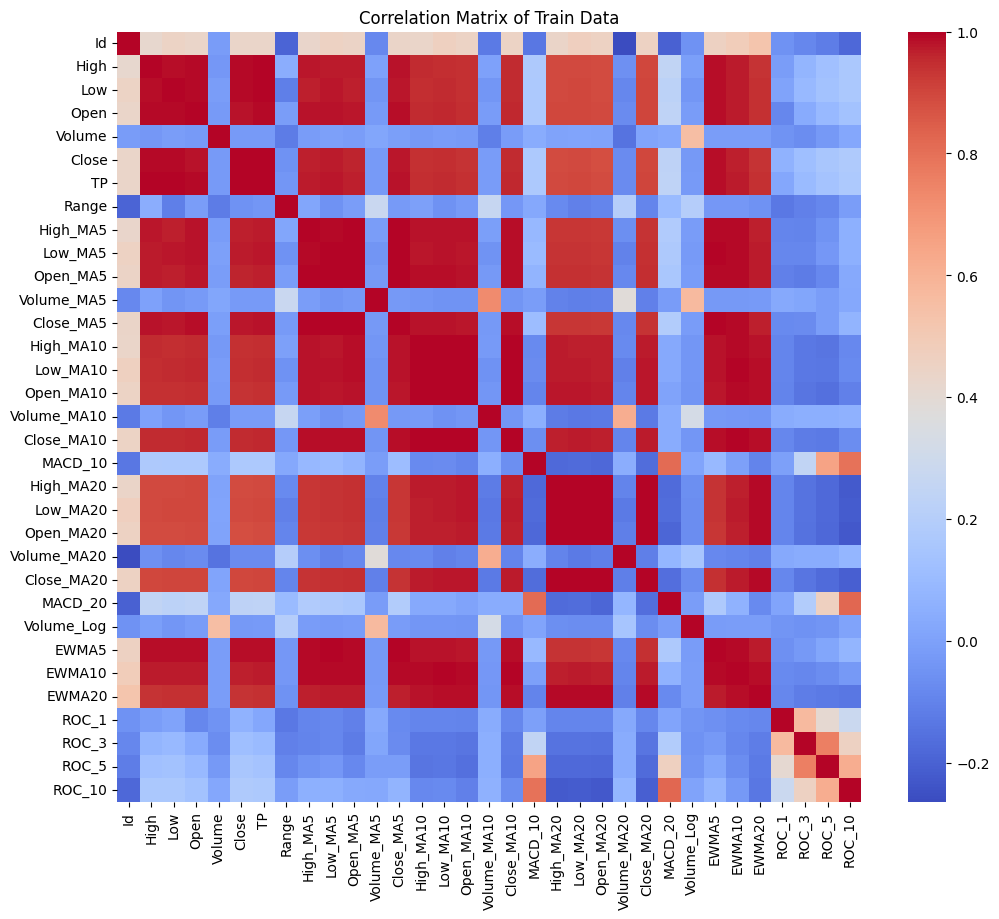

In [54]:
# prompt: plot correlation of train_data

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = train_data.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Train Data')
plt.show()


In [55]:
# prompt: display correlation btween Close and rest of data

# Display correlation between 'Close' and other features
correlation_with_close = correlation_matrix['Close'].sort_values(ascending=False)
correlation_with_close


,Close
Close,1.000000
TP,0.998264
Low,0.994555
High,0.991687
EWMA5,0.986295
Open,0.984890
Close_MA5,0.977321
Low_MA5,0.972010
High_MA5,0.968821
EWMA10,0.968741


In [56]:
# สร้างลำดับต่อเนื่องของข้อมูลสำหรับใช้กับ LSTM
def create_sequences(data, target_col, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data.iloc[i:i+seq_length].values)
        y.append(data.iloc[i+seq_length][target_col])
    return np.array(X), np.array(y)

In [57]:
# กำหนดความยาวของลำดับข้อมูล (sequence length)
SEQ_LENGTH = 10

In [58]:
# ลบแถวที่มี missing values เนื่องจากการสร้างฟีเจอร์ใหม่
train_data = train_data.dropna()

In [59]:
# แยกข้อมูลและสร้าง sequence สำหรับใช้กับ LSTM
train_features = train_data.drop(['Id', 'Close', 'MACD_20', 'ROC_10',
                                  'MACD_10', 'ROC_5', 'ROC_3', 'ROC_1',
                                  'Volume_MA10', 'Volume', 'Volume_MA5',
                                  'Volume_Log', 'Range', 'Volume_MA20'], axis=1)
train_target = train_data['Close']

In [60]:
# สร้าง scaler สำหรับ normalize ข้อมูล
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

In [61]:
# Normalize ข้อมูล features และ target
train_features_scaled = scaler_X.fit_transform(train_features)
train_target_scaled = scaler_y.fit_transform(train_target.values.reshape(-1, 1))

In [62]:
# สร้าง sequence สำหรับใช้กับ LSTM
X_scaled = np.array([train_features_scaled[i:i+SEQ_LENGTH] for i in range(len(train_features_scaled)-SEQ_LENGTH)])
y_scaled = train_target_scaled[SEQ_LENGTH:]

In [63]:
print("LSTM input shape:", X_scaled.shape)
print("LSTM output shape:", y_scaled.shape)

LSTM input shape: (614, 10, 19)
LSTM output shape: (614, 1)


In [64]:
# สร้างโมเดล LSTM
def create_lstm_model(input_shape):
    model = Sequential([
        LSTM(100, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(50),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

In [65]:
# ขนาดของข้อมูลที่จะใช้ในการสร้างโมเดล
input_shape = (X_scaled.shape[1], X_scaled.shape[2])

In [66]:
# สร้างโมเดล
model = create_lstm_model(input_shape)
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                       │ (None, 10, 100)             │          48,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 10, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,501 (310.55 KB)

 Trainable params: 79,501 (310.55 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# การหยุดเทรนก่อนกำหนดถ้าผลลัพธ์ไม่ดีขึ้น
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [68]:
# เทรนโมเดล
history = model.fit(
    X_scaled, y_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - loss: 0.1077 - val_loss: 0.0087
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0163 - val_loss: 0.0083
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0097 - val_loss: 0.0084
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0113 - val_loss: 0.0086
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0102 - val_loss: 0.0062
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0098 - val_loss: 0.0056
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0100 - val_loss: 0.0054
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0078 - val_loss: 0.0060
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0078 - val_loss: 0.0060
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0076 - val_loss: 0.0045
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

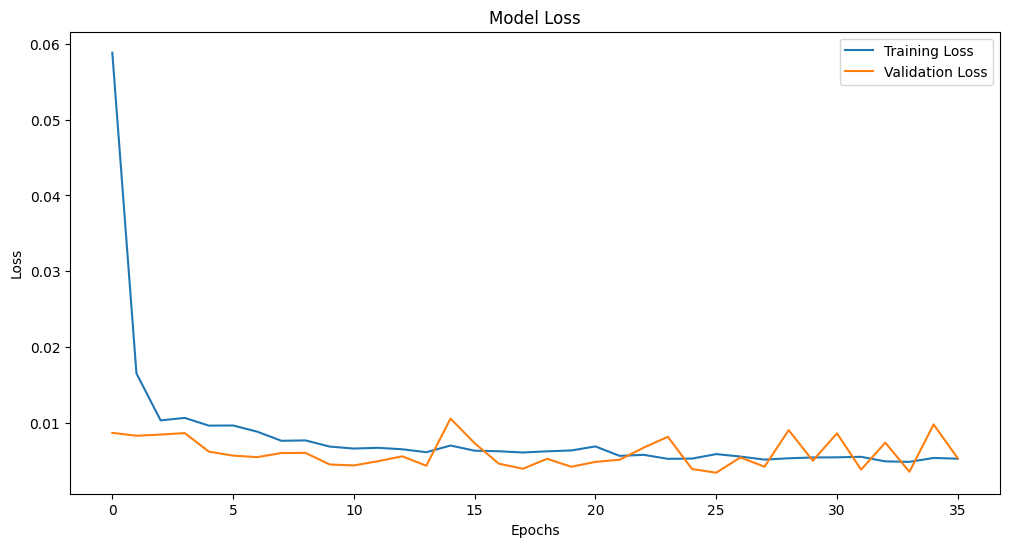

In [71]:
# แสดงกราฟการเรียนรู้ของโมเดล
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [81]:
# เตรียมข้อมูลทดสอบ
# เพิ่มฟีเจอร์ให้กับข้อมูลทดสอบ
X_test_copy = X_test.copy()

In [85]:
# สร้างข้อมูลผสมระหว่าง train และ test สำหรับคำนวณฟีเจอร์ rolling
# โดยที่ข้อมูล train สุดท้ายต่อด้วยข้อมูล test
combined_data = pd.concat([
    train_data[['Id', 'High', 'Low', 'Open', 'Volume', 'Close']],
    X_test_copy
])

In [83]:
# เพิ่มฟีเจอร์ให้กับข้อมูลรวม
combined_data = add_features(combined_data)

<ipython-input-52-eb10dd20cbd3>:44: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'ROC_{period}'] = df['Close'].pct_change(periods=period)
<ipython-input-52-eb10dd20cbd3>:44: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'ROC_{period}'] = df['Close'].pct_change(periods=period)
<ipython-input-52-eb10dd20cbd3>:44: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df[f'ROC_{period}'] = df['Close'].p

In [88]:
combined_data

,Id,High,Low,Open,Volume,Close
19,19,1585.000000,1571.400024,1576.800049,62336,1583.500000
20,20,1589.000000,1570.000000,1573.400024,1095,1582.900024
21,21,1593.300049,1568.199951,1592.900024,1062,1577.199951
22,22,1577.699951,1547.800049,1577.699951,978,1550.400024
23,23,1560.699951,1547.699951,1553.199951,1305,1557.800049
...,...,...,...,...,...,...
638,1281,2880.500000,2848.000000,2850.000000,4519,NaN
639,1282,2871.699951,2836.300049,2865.199951,3116,NaN
640,1283,2889.500000,2857.800049,2859.899902,1822,NaN
641,1284,2916.100098,2863.800049,2864.199951,2237,NaN


In [ ]:
train_features = train_data.drop(['Id', 'Close', 'MACD_20', 'ROC_10',
                                  'MACD_10', 'ROC_5', 'ROC_3', 'ROC_1',
                                  'Volume_MA10', 'Volume', 'Volume_MA5',
                                  'Volume_Log', 'Range', 'Volume_MA20'], axis=1)

In [ ]:
# แยกข้อมูลทดสอบออกมา
test_data = combined_data[combined_data['Id'] >= X_test['Id'].min()]

In [76]:
# เตรียมข้อมูลทดสอบสำหรับทำนาย
# แต่ละแถวจะใช้ข้อมูล SEQ_LENGTH แถวก่อนหน้าในการทำนาย
predictions = []

In [77]:
# สำหรับแต่ละวันใน test set
for idx in range(len(X_test)):
    # หา index ของวันนั้นใน combined_data
    current_id = X_test.iloc[idx]['Id']
    current_idx = combined_data[combined_data['Id'] == current_id].index[0]

    # ถ้ามีข้อมูลเพียงพอสำหรับการทำนาย (ต้องมีข้อมูลย้อนหลังอย่างน้อย SEQ_LENGTH วัน)
    if current_idx >= SEQ_LENGTH:
        # ดึงข้อมูลย้อนหลัง SEQ_LENGTH วัน
        sequence = combined_data.iloc[current_idx-SEQ_LENGTH:current_idx]

        # เลือกเฉพาะคอลัมน์ที่ใช้ในการเทรน (ต้องตรงกับ train_features)
        sequence_features = sequence[train_features.columns]

        # Normalize ข้อมูล
        sequence_scaled = scaler_X.transform(sequence_features)

        # ปรับรูปร่างข้อมูลให้เหมาะกับ LSTM (batch_size=1, seq_length, n_features)
        sequence_reshaped = sequence_scaled.reshape(1, SEQ_LENGTH, sequence_scaled.shape[1])

        # ทำนายด้วยโมเดล
        pred_scaled = model.predict(sequence_reshaped, verbose=0)

        # แปลงค่าที่ทำนายได้กลับไปเป็นค่าจริง
        pred = scaler_y.inverse_transform(pred_scaled)[0][0]
        predictions.append({'Id': current_id, 'Close': pred})
    else:
        # ถ้าข้อมูลไม่เพียงพอ ใช้ค่าเฉลี่ยของข้อมูลที่มีอยู่
        last_close = train_data['Close'].iloc[-1]
        predictions.append({'Id': current_id, 'Close': last_close})

In [78]:
# สร้าง DataFrame จากผลการทำนาย
predictions_df = pd.DataFrame(predictions)

In [79]:
# ปรับ Id ให้เป็นวันถัดไป (เนื่องจากเราต้องการทำนายราคาปิด 1 วันล่วงหน้า)
predictions_df

,Id,Close
0,643.0,1712.699951
1,644.0,1712.699951
2,645.0,1712.699951
3,646.0,1712.699951
4,647.0,1712.699951
...,...,...
638,1281.0,NaN
639,1282.0,NaN
640,1283.0,NaN
641,1284.0,NaN


In [ ]:



\\

# ปรับ Id ให้เป็นวันถัดไป (เนื่องจากเราต้องการทำนายราคาปิด 1 วันล่วงหน้า)
predictions_df['Id'] = predictions_df['Id']

# บันทึกผลลัพธ์
predictions_df.to_csv('submission.csv', index=False)

print("Predictions saved to submission.csv")

# แสดงกราฟเปรียบเทียบการทำนาย
plt.figure(figsize=(15, 8))
plt.plot(predictions_df['Id'], predictions_df['Close'], label='Predicted Close', color='red')
plt.title('Predicted Stock Prices')
plt.xlabel('Day')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.savefig('predictions.png')
plt.close()

print("Prediction visualization saved to predictions.png")